(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

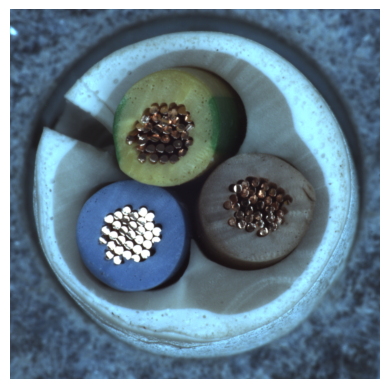

In [90]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("data/test/cut_outer_insulation/002.png")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

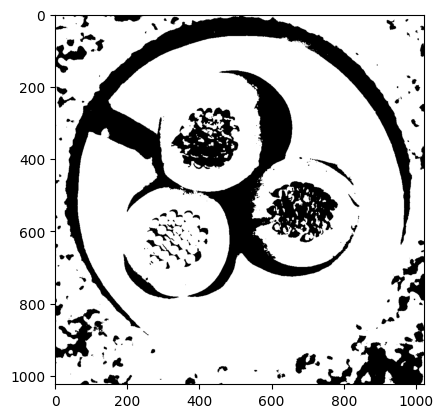

In [91]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
(T , thresh) = cv2.threshold(img_gray, 70, 255, cv2.THRESH_BINARY)
plt.imshow(thresh, cmap='gray')


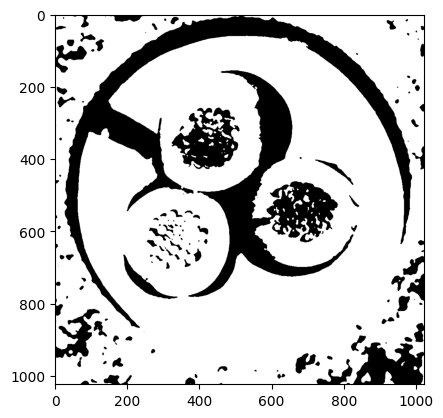

In [92]:
median = cv2.medianBlur(thresh, 5)
plt.imshow(median, cmap='gray')


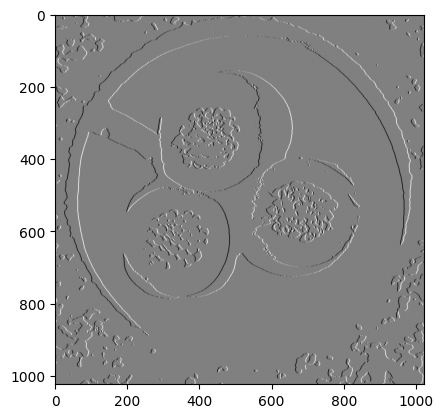

In [93]:
sobelx = cv2.Sobel(thresh, cv2.CV_64F, 1, 0, ksize=3)
plt.imshow(sobelx, cmap='gray')


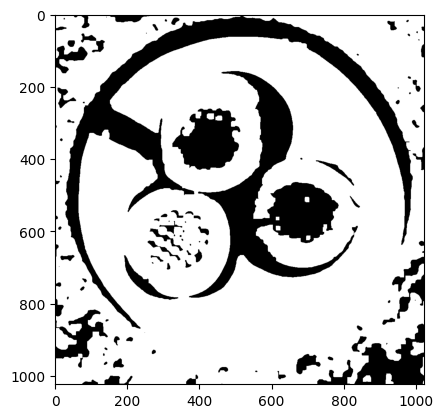

In [94]:
kernel1 = np.ones((4, 4), np.uint8)

eroded = cv2.erode(median, kernel1, iterations=3) 
    #DILATATION
kernel2 = np.ones((10, 10), np.uint8)
img_dilation = cv2.dilate(eroded, kernel2, iterations=1)
plt.imshow(img_dilation, cmap='gray') 


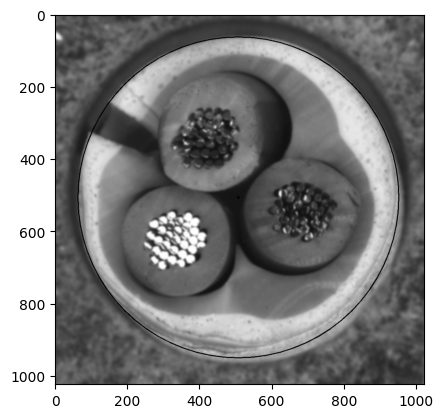

In [95]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(img_gray, (9, 9), 2)
output = blur.copy()

circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=200,
    maxRadius=500
)


# Draw only the first detected circle
if circles is not None:
    circles = np.uint16(np.around(circles))
    x, y, r = circles[0][0]
    cv2.circle(output, (x, y), r, (0, 255, 0), 2)  # Circle outline
    cv2.circle(output, (x, y), 2, (0, 0, 255), 3)  # Center point
plt.imshow(output, cmap='gray')

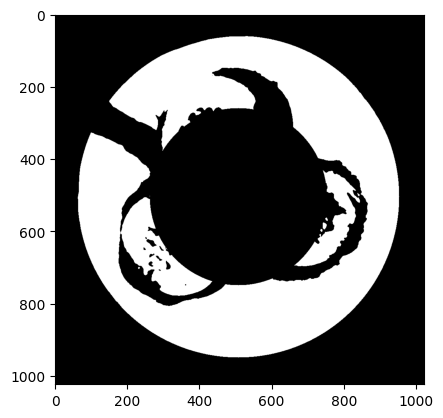

In [99]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(img_gray, (9, 9), 2)
(T , thresh) = cv2.threshold(blur, 90, 255, cv2.THRESH_BINARY)

blur = thresh
circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=200,
    maxRadius=500
)

# Domyślnie całe czarne
masked = np.zeros_like(img_gray, dtype=np.uint8)

if circles is not None:
    circles = np.uint16(np.around(circles))
    x, y, r = circles[0][0]
    r2 = r - 200  # promień wewnętrzny
    
    # Tworzymy dwie maski
    mask_outer = np.zeros_like(img_gray, dtype=np.uint8)
    mask_inner = np.zeros_like(img_gray, dtype=np.uint8)
    
    cv2.circle(mask_outer, (x, y), r, 255, -1)  # większy okrąg
    cv2.circle(mask_inner, (x, y), r2, 255, -1)  # mniejszy okrąg
    
    # Pierścień = większy okrąg minus mniejszy
    ring_mask = cv2.subtract(mask_outer, mask_inner)
    
    # Nałożenie pierścienia na obraz
    masked = cv2.bitwise_and(thresh, thresh, mask=ring_mask)
    
plt.imshow(masked, cmap='gray')

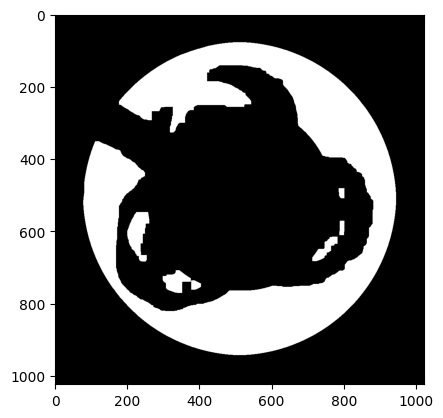

In [97]:
(T , thresh) = cv2.threshold(masked, 90, 255, cv2.THRESH_BINARY)
median = cv2.medianBlur(thresh, 5)

kernel1 = np.ones((6, 6), np.uint8)
eroded = cv2.erode(median, kernel1, iterations=6) 
    #DILATATION
kernel2 = np.ones((10, 10), np.uint8)
img_dilation = cv2.dilate(eroded, kernel2, iterations=1)
plt.imshow(img_dilation, cmap='gray') 

